<a href="https://colab.research.google.com/github/hamishch47/Fraud-detection-using-deep-learning/blob/main/Fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fraud Detection Using Deep Learning

## Introduction

Online payment fraud is a growing threat to financial institutions and consumers worldwide. With the rapid growth of digital transactions, traditional rule-based fraud detection systems struggle to keep pace with increasingly sophisticated fraud patterns. This project explores the use of **deep learning** combined with **adaptive streaming techniques** to build a robust fraud detection system.

### Motivation
- Fraud patterns evolve over time (concept drift), making static models less effective.
- Class imbalance is extreme — fraud cases are typically < 4% of all transactions.
- Real-world systems must process transactions as a stream with delayed label feedback.

### Approach
1. **Baseline Models**: We train traditional ML classifiers (XGBoost, Random Forest, SVM, KNN) on historical data.
2. **Deep Learning (MLP)**: A multi-layer perceptron with batch normalization and dropout serves as our primary model.
3. **MC Dropout Uncertainty**: Monte Carlo Dropout estimates prediction uncertainty at inference time.
4. **Adaptive Streaming**: Using ADWIN drift detection and an uncertainty-driven replay buffer, the model adapts to distributional shifts in the transaction stream.

### Dataset
We use the [IEEE-CIS Fraud Detection](https://www.kaggle.com/c/ieee-fraud-detection) dataset from Kaggle, which contains real-world e-commerce transaction data with engineered features.

### Metrics
- **ROC-AUC**: Area under the Receiver Operating Characteristic curve.
- **PR-AUC**: Area under the Precision-Recall curve (more informative for imbalanced data).
- **Recall@5%FPR**: Recall achieved at a 5% false positive rate threshold.

# 1. SETUP & IMPORTS

In [1]:
!pip install kaggle river torch torchvision torchaudio scikit-learn xgboost lightgbm category-encoders --quiet

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import xgboost as xgb
import seaborn as sns
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (precision_recall_curve, roc_auc_score, roc_curve,
                             auc, recall_score, confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from category_encoders import TargetEncoder
from river.drift import ADWIN
from collections import deque
import matplotlib.pyplot as plt
import joblib
import os
import gc
import json
from pathlib import Path

# Reproducibility seeds
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('seaborn-whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def clear_memory():
    """Free unused GPU and CPU memory."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def print_gpu_memory():
    """Print current GPU memory usage."""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**2
        reserved = torch.cuda.memory_reserved() / 1024**2
        print(f"GPU Memory - Allocated: {allocated:.1f}MB, Reserved: {reserved:.1f}MB")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 87.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
Using device: cuda


# 2. SECURE KAGGLE DATA DOWNLOAD

In [2]:
from google.colab import files
print("Please upload your kaggle.json file now:")
files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c ieee-fraud-detection -p /content/data
!unzip -q /content/data/ieee-fraud-detection.zip -d /content/data


Please upload your kaggle.json file now:


Saving kaggle.json to kaggle.json
100% 118M/118M [00:09<00:00, 13.2MB/s]



# 3. DATA & PREPROCESSING

In [3]:
# Load data
train_tr = pd.read_csv('/content/data/train_transaction.csv')
train_id = pd.read_csv('/content/data/train_identity.csv')
data = train_tr.merge(train_id, on='TransactionID', how='left')

# Define expanded feature set
target_col = 'isFraud'
time_col = 'TransactionDT'

# Build comprehensive feature list (excluding time column from features)
# Note: time_col will be kept in data for sorting and feature engineering,
# but excluded from the final feature set used for model input
feature_cols = [
    'TransactionAmt', 'ProductCD',
    'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    'addr1', 'addr2', 'dist1', 'dist2',
    'P_emaildomain', 'R_emaildomain',
    'DeviceType', 'DeviceInfo'
] + [f'C{i}' for i in range(1, 15)] + [f'V{i}' for i in range(1, 340)]

# Filter to only existing columns
feature_cols = [c for c in feature_cols if c in data.columns]
print(f"Total features available: {len(feature_cols)}")

# Select features + target + time column, then sort by time for streaming simulation
# Keep time_col in data for feature engineering but not in feature_cols
data = data[feature_cols + [target_col, time_col]].sort_values(time_col).reset_index(drop=True)

# Feature Engineering: Time-based features (using TransactionDT)
data['TransactionHour'] = (data['TransactionDT'] // 3600) % 24
data['TransactionDay'] = data['TransactionDT'] // (3600 * 24)
data['TransactionDayOfWeek'] = (data['TransactionDay'] % 7)

# Feature Engineering: Amount-based features
data['TransactionAmt_log'] = np.log1p(data['TransactionAmt'])
data['TransactionAmt_decimal'] = data['TransactionAmt'] - data['TransactionAmt'].astype(int)
data['TransactionAmt_rounded'] = (data['TransactionAmt'] == data['TransactionAmt'].round()).astype(int)

# Add engineered features to feature list
engineered_features = ['TransactionHour', 'TransactionDay', 'TransactionDayOfWeek',
                       'TransactionAmt_log', 'TransactionAmt_decimal', 'TransactionAmt_rounded']
feature_cols.extend(engineered_features)

# Now drop the raw time column as it's no longer needed
# (time-based features have been created from it)
data = data.drop(columns=[time_col])

# Split: 60% Historical (Train), 40% Streaming (Test)
split_idx = int(0.6 * len(data))
hist_df = data.iloc[:split_idx].reset_index(drop=True)
stream_df = data.iloc[split_idx:].reset_index(drop=True)
del data
clear_memory()

# Handling Missing Values
for col in feature_cols:
    if col in hist_df.columns:
        if hist_df[col].dtype == 'O':
            hist_df[col] = hist_df[col].fillna('missing')
            stream_df[col] = stream_df[col].fillna('missing')
        else:
            median_val = hist_df[col].median()
            hist_df[col] = hist_df[col].fillna(median_val)
            stream_df[col] = stream_df[col].fillna(median_val)

# Identify categorical columns for TargetEncoder
cat_cols = ['ProductCD', 'card4', 'card6', 'DeviceType',
            'P_emaildomain', 'R_emaildomain', 'DeviceInfo']
cat_cols = [c for c in cat_cols if c in hist_df.columns]
print(f"Categorical features for target encoding: {len(cat_cols)}")

# Apply TargetEncoder (fit on historical, transform streaming)
te = TargetEncoder(cols=cat_cols)
hist_df[cat_cols] = te.fit_transform(hist_df[cat_cols], hist_df[target_col])
stream_df[cat_cols] = te.transform(stream_df[cat_cols])

# Feature Engineering: Card aggregations (computed from historical split only)
for card_col in ['card1', 'card2', 'card3']:
    if card_col in hist_df.columns:
        card_stats = hist_df.groupby(card_col)[target_col].agg(['mean', 'count'])
        card_stats.columns = [f'{card_col}_fraud_rate', f'{card_col}_count']
        hist_df = hist_df.merge(card_stats, on=card_col, how='left')
        stream_df = stream_df.merge(card_stats, on=card_col, how='left')

        # Fill NaN values for unseen cards
        stream_df[f'{card_col}_fraud_rate'] = stream_df[f'{card_col}_fraud_rate'].fillna(hist_df[target_col].mean())
        stream_df[f'{card_col}_count'] = stream_df[f'{card_col}_count'].fillna(0)
        hist_df[f'{card_col}_fraud_rate'] = hist_df[f'{card_col}_fraud_rate'].fillna(hist_df[target_col].mean())
        hist_df[f'{card_col}_count'] = hist_df[f'{card_col}_count'].fillna(0)

        feature_cols.extend([f'{card_col}_fraud_rate', f'{card_col}_count'])

# Identify numeric columns (all non-target features after encoding)
num_cols = [c for c in feature_cols if c in hist_df.columns and c != target_col]


from sklearn.decomposition import PCA

# Identify V-columns
v_cols = [c for c in num_cols if c.startswith('V')]
non_v_cols = [c for c in num_cols if not c.startswith('V')]

print(f"V-columns: {len(v_cols)}, Non-V columns: {len(non_v_cols)}")

# PCA on V-columns (reduce 339 → 50 components, retains ~95% variance)
n_components = 50
pca = PCA(n_components=n_components, random_state=42)

hist_v_pca = pca.fit_transform(hist_df[v_cols].values.astype(np.float32))
stream_v_pca = pca.transform(stream_df[v_cols].values.astype(np.float32))

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.4f}")

# Create new PCA column names and add to dataframes
pca_col_names = [f'V_pca_{i}' for i in range(n_components)]
for i, col_name in enumerate(pca_col_names):
    hist_df[col_name] = hist_v_pca[:, i]
    stream_df[col_name] = stream_v_pca[:, i]

# Update feature list: replace V-columns with PCA components
feature_input_cols = non_v_cols + pca_col_names
print(f"Reduced feature count: {len(feature_input_cols)} (was 381)")

del hist_v_pca, stream_v_pca
clear_memory()

# Update num_cols to reflect reduced feature set
num_cols = feature_input_cols

# Scaling Numerics
scaler = StandardScaler()
hist_df[num_cols] = scaler.fit_transform(hist_df[num_cols])
stream_df[num_cols] = scaler.transform(stream_df[num_cols])

# Save input feature order
feature_input_cols = num_cols

# Calculate Class Weight for Imbalance
neg_count = (hist_df[target_col] == 0).sum()
pos_count = (hist_df[target_col] == 1).sum()
pos_weight = torch.tensor([neg_count / pos_count]).to(device)

print(f"Historical set: {len(hist_df)}, Streaming set: {len(stream_df)}")
print(f"Fraud Ratio: {pos_count/len(hist_df):.4f}, Pos Weight: {pos_weight.item():.2f}")
print(f"Total input features: {len(feature_input_cols)}")

Total features available: 369
Categorical features for target encoding: 7
V-columns: 339, Non-V columns: 42
PCA explained variance: 1.0000
Reduced feature count: 92 (was 381)
Historical set: 354324, Streaming set: 236216
Fraud Ratio: 0.0338, Pos Weight: 28.56
Total input features: 92


# 4. Utility Functions: Metrics

In [4]:
def mc_predict(model, X, T=20):
    model.eval() # Set model to evaluation mode (disables Batchnorm training and Dropout)
    # Manually re-enable dropout layers for MC Dropout
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train() # Re-enable dropout

    probs = []
    with torch.no_grad():
        for _ in range(T):
            logits = model(X)
            probs.append(torch.sigmoid(logits).cpu().numpy())
    probs = np.stack(probs, axis=0)

    # Restore original model state (eval mode for all layers) after MC Dropout
    model.eval()

    # Return mean prob and variance
    return probs.mean(axis=0).reshape(-1), probs.var(axis=0).reshape(-1)

def compute_metrics(y_true, y_score):
    if len(np.unique(y_true)) < 2: return None
    roc = roc_auc_score(y_true, y_score)
    pr, rc, _ = precision_recall_curve(y_true, y_score)

    # Recall at 5% FPR
    fpr_target = 0.05
    # Sort scores descending
    desc_score_indices = np.argsort(y_score)[::-1]
    y_score_sorted = np.array(y_score)[desc_score_indices]
    y_true_sorted = np.array(y_true)[desc_score_indices]

    # Find threshold index for 5% FPR
    neg_count = (y_true_sorted == 0).sum()
    fp_limit = neg_count * fpr_target
    fp_count = 0
    cutoff_idx = len(y_true_sorted)

    for i, label in enumerate(y_true_sorted):
        if label == 0: fp_count += 1
        if fp_count > fp_limit:
            cutoff_idx = i
            break

    # Calculate recall up to that cutoff
    if np.sum(y_true_sorted) > 0:
        recall_at_fpr = np.sum(y_true_sorted[:cutoff_idx]) / np.sum(y_true_sorted)
    else:
        recall_at_fpr = 0.0

    return {"roc_auc": roc, "pr_auc": auc(rc, pr), "recall_at_5fpr": recall_at_fpr}

# 5. BASELINE: XGBoost

In [5]:
print("\nTraining XGBoost Baseline...")
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    scale_pos_weight=pos_weight.item(),
    eval_metric='auc'
)
xgb_clf.fit(hist_df[feature_input_cols], hist_df[target_col])

# Save the model immediately before deleting the object to free memory
os.makedirs('results', exist_ok=True)
xgb_clf.get_booster().save_model('results/xgb_model.json')
print("XGBoost model saved to results/xgb_model.json")

y_pred_xgb = xgb_clf.predict_proba(stream_df[feature_input_cols])[:, 1]
xgb_feature_importances = xgb_clf.feature_importances_.copy()

del xgb_clf
clear_memory()
y_true_stream = stream_df[target_col].values

xgb_metrics = compute_metrics(y_true_stream, y_pred_xgb)
print(f"XGBoost — ROC-AUC: {xgb_metrics['roc_auc']:.4f}, "
      f"PR-AUC: {xgb_metrics['pr_auc']:.4f}, "
      f"Recall@5%FPR: {xgb_metrics['recall_at_5fpr']:.4f}")


Training XGBoost Baseline...
XGBoost model saved to results/xgb_model.json
XGBoost — ROC-AUC: 0.8083, PR-AUC: 0.4059, Recall@5%FPR: 0.5137


# 5B. Additional Baselines: Random Forest, Logistic Regression, LightGBM


In [6]:
# --- Random Forest ---
print("Training Random Forest...")
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(hist_df[feature_input_cols], hist_df[target_col])
y_pred_rf = rf_clf.predict_proba(stream_df[feature_input_cols])[:, 1]
del rf_clf
rf_metrics = compute_metrics(y_true_stream, y_pred_rf)
print(f"Random Forest — ROC-AUC: {rf_metrics['roc_auc']:.4f}, "
      f"PR-AUC: {rf_metrics['pr_auc']:.4f}, "
      f"Recall@5%FPR: {rf_metrics['recall_at_5fpr']:.4f}")

# --- Logistic Regression (Memory-Optimized) ---
print("\nTraining Logistic Regression...")

# Downcast to float32 to halve memory usage
X_train_lr = hist_df[feature_input_cols].values.astype(np.float32)
y_train_lr = hist_df[target_col].values

lr_clf = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    solver='saga',       # Much more memory-efficient for large datasets
    penalty='l1',
    C=0.1,
    max_iter=100,        # saga converges faster, fewer iterations needed
    tol=1e-3,            # Relax tolerance for faster convergence
    n_jobs=-1            # Parallelize across cores
)
lr_clf.fit(X_train_lr, y_train_lr)
y_pred_lr = lr_clf.predict_proba(stream_df[feature_input_cols].values.astype(np.float32))[:, 1]

del X_train_lr, y_train_lr, lr_clf
clear_memory()

lr_metrics = compute_metrics(y_true_stream, y_pred_lr)
print(f"Logistic Regression — ROC-AUC: {lr_metrics['roc_auc']:.4f}, "
      f"PR-AUC: {lr_metrics['pr_auc']:.4f}, "
      f"Recall@5%FPR: {lr_metrics['recall_at_5fpr']:.4f}")

from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight

print("\nTraining SGD Logistic Regression (streaming-friendly)...")

# Calculate class weights manually for SGDClassifier with partial_fit
classes = np.array([0, 1])
class_weights_dict = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=hist_df[target_col].values # Use the full historical dataset to compute weights
)
class_weights_dict = dict(zip(classes, class_weights_dict))


# SGDClassifier with log_loss = logistic regression via SGD
sgd_clf = SGDClassifier(
    loss='log_loss',           # Logistic regression
    penalty='l1',
    alpha=1 / (0.1 * len(hist_df)),  # Equivalent to C=0.1
    class_weight=class_weights_dict, # Pass the computed dictionary here
    random_state=42,
    max_iter=100,
    tol=1e-3,
    n_jobs=-1
)

# Train with partial_fit in chunks to limit peak memory
chunk_size = 50000
X_train = hist_df[feature_input_cols].values.astype(np.float32)
y_train = hist_df[target_col].values

for epoch in range(10):
    indices = np.random.permutation(len(X_train))
    for start in range(0, len(X_train), chunk_size):
        end = min(start + chunk_size, len(X_train))
        batch_idx = indices[start:end]
        sgd_clf.partial_fit(X_train[batch_idx], y_train[batch_idx], classes=classes)

# Wrap in CalibratedClassifierCV for proper probability estimates
cal_clf = CalibratedClassifierCV(sgd_clf, cv='prefit', method='sigmoid')
cal_clf.fit(X_train[:50000], y_train[:50000])  # Calibrate on subset

y_pred_sgd = cal_clf.predict_proba(
    stream_df[feature_input_cols].values.astype(np.float32)
)[:, 1]

del sgd_clf, cal_clf, X_train, y_train
clear_memory()

sgd_metrics = compute_metrics(y_true_stream, y_pred_sgd)
print(f"SGD Logistic Regression — ROC-AUC: {sgd_metrics['roc_auc']:.4f}, "
      f"PR-AUC: {sgd_metrics['pr_auc']:.4f}, "
      f"Recall@5%FPR: {sgd_metrics['recall_at_5fpr']:.4f}")

# --- LightGBM ---
print("\nTraining LightGBM...")
lgb_clf = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
lgb_clf.fit(hist_df[feature_input_cols], hist_df[target_col])
y_pred_lgb = lgb_clf.predict_proba(stream_df[feature_input_cols])[:, 1]
del lgb_clf
lgb_metrics = compute_metrics(y_true_stream, y_pred_lgb)
print(f"LightGBM — ROC-AUC: {lgb_metrics['roc_auc']:.4f}, "
      f"PR-AUC: {lgb_metrics['pr_auc']:.4f}, "
      f"Recall@5%FPR: {lgb_metrics['recall_at_5fpr']:.4f}")
clear_memory()

Training Random Forest...
Random Forest — ROC-AUC: 0.8602, PR-AUC: 0.4123, Recall@5%FPR: 0.5250

Training Logistic Regression...
Logistic Regression — ROC-AUC: 0.8173, PR-AUC: 0.1864, Recall@5%FPR: 0.3710

Training SGD Logistic Regression (streaming-friendly)...


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


SGD Logistic Regression — ROC-AUC: 0.6900, PR-AUC: 0.1355, Recall@5%FPR: 0.3245

Training LightGBM...
LightGBM — ROC-AUC: 0.8214, PR-AUC: 0.4102, Recall@5%FPR: 0.5141


# 6. DEEP LEARNING MODEL

In [7]:
class FraudDataset(Dataset):
    def __init__(self, df):
        self.X = torch.tensor(df[feature_input_cols].values, dtype=torch.float32)
        self.y = torch.tensor(df[target_col].values, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance by focusing on hard examples."""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = nn.functional.binary_cross_entropy_with_logits(
            inputs, targets, reduction='none'
        )
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

class ImprovedMLP(nn.Module):
    """Improved MLP with deeper architecture and no BatchNorm (for MC-Dropout)."""
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 32)
        self.fc5 = nn.Linear(32, 1)

        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.dropout(self.relu(self.fc3(x)))
        x = self.dropout(self.relu(self.fc4(x)))
        return self.fc5(x)

# Keep old MLP for backwards compatibility
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.net(x)

# 7. Initial Training (Static Baseline)

In [8]:
# Ensure clean GPU state before training
clear_memory()
print_gpu_memory()

# Split historical data into train/validation (80/20)
val_split_idx = int(0.8 * len(hist_df))
train_subset = hist_df.iloc[:val_split_idx].reset_index(drop=True)
val_subset = hist_df.iloc[val_split_idx:].reset_index(drop=True)

train_ds = FraudDataset(train_subset)
val_ds = FraudDataset(val_subset)

# WeightedRandomSampler: oversample positives so fraud examples are seen more often
train_labels = train_subset[target_col].values.astype(int)
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts  # inverse-frequency weights
sample_weights = torch.tensor(class_weights[train_labels], dtype=torch.float32)
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# Training loader uses sampler; validation loader stays sequential (true distribution)
train_loader = DataLoader(train_ds, batch_size=1024, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=1024, shuffle=False)

# Initialize improved model
model = ImprovedMLP(input_dim=len(feature_input_cols)).to(device)

# BCEWithLogitsLoss with pos_weight — strongest simple imbalance baseline
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# AdamW: weight_decay adds L2 regularisation; lr=3e-4 is a robust default
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

# Mixed precision scaler
from torch.amp import GradScaler, autocast
scaler_amp = GradScaler('cuda')

# LR scheduler in 'max' mode to track val PR-AUC
from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

# Training with early stopping on validation PR-AUC
training_losses = []
best_val_pr_auc = -1.0
patience_counter = 0
max_patience = 5

print("\nTraining Improved Model with Validation Split...")
print(f"Train size: {len(train_ds)}, Val size: {len(val_ds)}")

for epoch in range(20):
    # Training phase
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device).view(-1, 1)
        optimizer.zero_grad()
        with autocast('cuda'):
            out = model(X_batch)
            loss = criterion(out, y_batch)
        scaler_amp.scale(loss).backward()
        # Gradient clipping to prevent exploding gradients
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler_amp.step(optimizer)
        scaler_amp.update()
        train_loss += loss.item() * len(X_batch)

    avg_train_loss = train_loss / len(train_ds)
    training_losses.append(avg_train_loss)

    # Validation phase: collect probs and compute PR-AUC / Recall@5%FPR
    model.eval()
    val_probs_list = []
    val_labels_list = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            out = model(X_batch)
            probs = torch.sigmoid(out).cpu().numpy().reshape(-1)
            val_probs_list.append(probs)
            val_labels_list.append(y_batch.numpy())

    val_probs_arr = np.concatenate(val_probs_list)
    val_labels_arr = np.concatenate(val_labels_list)
    val_metrics = compute_metrics(val_labels_arr, val_probs_arr)
    val_pr_auc = val_metrics['pr_auc']
    val_recall = val_metrics['recall_at_5fpr']

    # Step LR scheduler on val PR-AUC
    scheduler.step(val_pr_auc)

    print(f"Epoch {epoch+1}/20 - Train Loss: {avg_train_loss:.4f}, "
          f"Val PR-AUC: {val_pr_auc:.4f}, Val Recall@5%FPR: {val_recall:.4f}")

    # Early stopping: maximise val PR-AUC
    if val_pr_auc > best_val_pr_auc:
        best_val_pr_auc = val_pr_auc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"  → New best model saved (val_pr_auc: {best_val_pr_auc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= max_patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# Load best checkpoint (selected by val PR-AUC)
print(f"\nLoading best model (val_pr_auc: {best_val_pr_auc:.4f})")
model.load_state_dict(torch.load('best_model.pt'))

# Compute MLP static baseline metrics on stream data IN BATCHES
model.eval()
mlp_static_probs = []
batch_size = 4096
stream_tensor = torch.tensor(stream_df[feature_input_cols].values, dtype=torch.float32)
with torch.no_grad():
    for start in range(0, len(stream_tensor), batch_size):
        batch = stream_tensor[start:start+batch_size].to(device)
        probs = torch.sigmoid(model(batch)).cpu().numpy().reshape(-1)
        mlp_static_probs.append(probs)
        del batch
mlp_static_probs = np.concatenate(mlp_static_probs)
del stream_tensor
clear_memory()

mlp_static_metrics = compute_metrics(y_true_stream, mlp_static_probs)
print(f"\nMLP Static (Improved) — ROC-AUC: {mlp_static_metrics['roc_auc']:.4f}, "
      f"PR-AUC: {mlp_static_metrics['pr_auc']:.4f}, "
      f"Recall@5%FPR: {mlp_static_metrics['recall_at_5fpr']:.4f}")


GPU Memory - Allocated: 0.0MB, Reserved: 2.0MB

Training Improved Model with Validation Split...
Train size: 283459, Val size: 70865
Epoch 1/20 - Train Loss: 2.7684, Val PR-AUC: 0.3340, Val Recall@5%FPR: 0.4871
  → New best model saved (val_pr_auc: 0.3340)
Epoch 2/20 - Train Loss: 1.5368, Val PR-AUC: 0.3585, Val Recall@5%FPR: 0.5186
  → New best model saved (val_pr_auc: 0.3585)
Epoch 3/20 - Train Loss: 1.3838, Val PR-AUC: 0.3837, Val Recall@5%FPR: 0.5230
  → New best model saved (val_pr_auc: 0.3837)
Epoch 4/20 - Train Loss: 1.3161, Val PR-AUC: 0.4029, Val Recall@5%FPR: 0.5363
  → New best model saved (val_pr_auc: 0.4029)
Epoch 5/20 - Train Loss: 1.2681, Val PR-AUC: 0.4221, Val Recall@5%FPR: 0.5319
  → New best model saved (val_pr_auc: 0.4221)
Epoch 6/20 - Train Loss: 1.2329, Val PR-AUC: 0.4272, Val Recall@5%FPR: 0.5339
  → New best model saved (val_pr_auc: 0.4272)
Epoch 7/20 - Train Loss: 1.2032, Val PR-AUC: 0.4359, Val Recall@5%FPR: 0.5424
  → New best model saved (val_pr_auc: 0.4359)

# 8. EXPERIMENT: FULL METHOD

In [9]:
def run_full_method(df, delay=1000, chunk=50000):
    print("\nRunning Full Adaptive Method with Uncertainty & Drift Detection...")
    clear_memory()
    print_gpu_memory()
    adwin = ADWIN()
    label_queue = deque()
    replay_buffer = []
    drift_points = []
    metrics_log = []
    MAX_BUFFER_SIZE = 10000  # Add buffer size limit

    chunk_y_true, chunk_y_pred = [], []
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    for i in range(len(df)):
        row = df.iloc[i]
        X = torch.tensor(row[feature_input_cols].values, dtype=torch.float32).unsqueeze(0).to(device)
        y = int(row[target_col])

        # 1. Inference with Uncertainty
        mean_p, var_p = mc_predict(model, X)
        pred_prob = float(mean_p[0])

        chunk_y_true.append(y)
        chunk_y_pred.append(pred_prob)

        # 2. Delayed Label Queue
        is_uncertain = var_p[0] > 0.02 # Tune threshold if needed
        label_queue.append((X.detach().cpu(), y, is_uncertain))

        # 3. Label Reveal & Update
        if len(label_queue) > delay:
            past_X, past_y, was_uncertain = label_queue.popleft()

            # Drift Check
            model.eval()
            with torch.no_grad():
                drift_prob = torch.sigmoid(model(past_X.to(device))).item()
                drift_pred = 1 if drift_prob >= 0.5 else 0

            err = int(drift_pred != past_y)
            adwin.update(err)

            if adwin.drift_detected:
                drift_points.append(i)

            # Update Strategy
            if was_uncertain or adwin.drift_detected:
                replay_buffer.append((past_X, past_y))
            # Add buffer size limit
            if len(replay_buffer) > MAX_BUFFER_SIZE:
                replay_buffer = replay_buffer[-MAX_BUFFER_SIZE:]

            # Mini-batch update
            if len(replay_buffer) >= 64:
                batch = replay_buffer[-64:]
                bX = torch.cat([b[0] for b in batch]).to(device)
                by = torch.tensor([b[1] for b in batch], dtype=torch.float32).view(-1,1).to(device)

                model.train()
                optimizer.zero_grad()
                loss = criterion(model(bX), by)
                loss.backward()
                optimizer.step()
                replay_buffer = []

        # 4. Logging
        if (i+1) % chunk == 0:
            m = compute_metrics(chunk_y_true, chunk_y_pred)
            if m:
                m['index'] = i
                metrics_log.append(m)
                print(f"Index {i}: PR-AUC={m['pr_auc']:.4f}, Recall@5%FPR={m['recall_at_5fpr']:.4f}, Drifts={len(drift_points)}")
            chunk_y_true, chunk_y_pred = [], []
            clear_memory()

    return metrics_log, drift_points

# Run it!
metrics_log, drift_points = run_full_method(stream_df)


Running Full Adaptive Method with Uncertainty & Drift Detection...
GPU Memory - Allocated: 18.4MB, Reserved: 24.0MB
Index 49999: PR-AUC=0.2480, Recall@5%FPR=0.3290, Drifts=3
Index 99999: PR-AUC=0.3479, Recall@5%FPR=0.4326, Drifts=8
Index 149999: PR-AUC=0.2212, Recall@5%FPR=0.4066, Drifts=16
Index 199999: PR-AUC=0.2200, Recall@5%FPR=0.3923, Drifts=23


# 9. RESULTS & PLOTTING

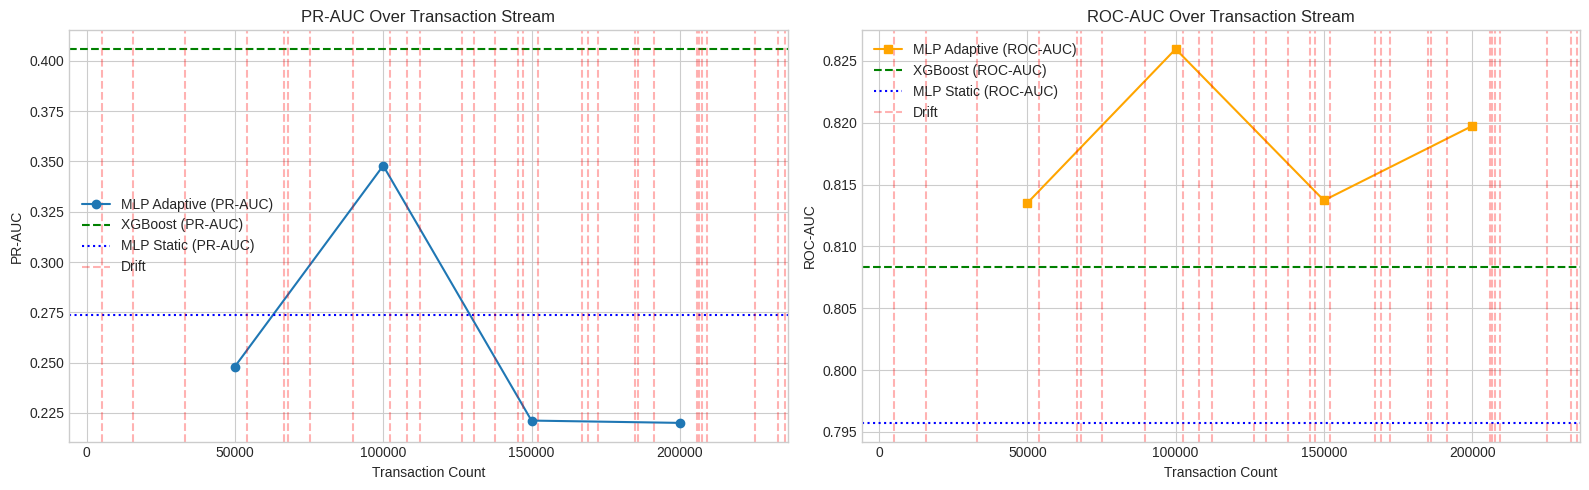

In [10]:
df_res = pd.DataFrame(metrics_log)

# Compute MLP Adaptive final metrics from the full streaming run
# (Use the last chunk's metrics if available, otherwise use overall)
if not df_res.empty:
    mlp_adaptive_metrics = {
        'roc_auc': df_res['roc_auc'].iloc[-1],
        'pr_auc': df_res['pr_auc'].iloc[-1],
        'recall_at_5fpr': df_res['recall_at_5fpr'].iloc[-1]
    }
else:
    mlp_adaptive_metrics = {'roc_auc': 0, 'pr_auc': 0, 'recall_at_5fpr': 0}

# --- Plot 9 (fixed): Adaptive Method Performance Over Stream ---
if not df_res.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # PR-AUC over stream
    axes[0].plot(df_res['index'], df_res['pr_auc'], marker='o', label='MLP Adaptive (PR-AUC)')
    axes[0].axhline(y=xgb_metrics['pr_auc'], color='g', linestyle='--', label='XGBoost (PR-AUC)')
    axes[0].axhline(y=mlp_static_metrics['pr_auc'], color='b', linestyle=':', label='MLP Static (PR-AUC)')
    first_drift = True
    for d in drift_points:
        if first_drift:
            axes[0].axvline(d, color='r', linestyle='--', alpha=0.3, label='Drift')
            first_drift = False
        else:
            axes[0].axvline(d, color='r', linestyle='--', alpha=0.3)
    axes[0].set_title('PR-AUC Over Transaction Stream')
    axes[0].set_xlabel('Transaction Count')
    axes[0].set_ylabel('PR-AUC')
    axes[0].legend()
    axes[0].grid(True)

    # ROC-AUC over stream
    axes[1].plot(df_res['index'], df_res['roc_auc'], marker='s', color='orange', label='MLP Adaptive (ROC-AUC)')
    axes[1].axhline(y=xgb_metrics['roc_auc'], color='g', linestyle='--', label='XGBoost (ROC-AUC)')
    axes[1].axhline(y=mlp_static_metrics['roc_auc'], color='b', linestyle=':', label='MLP Static (ROC-AUC)')
    first_drift = True
    for d in drift_points:
        if first_drift:
            axes[1].axvline(d, color='r', linestyle='--', alpha=0.3, label='Drift')
            first_drift = False
        else:
            axes[1].axvline(d, color='r', linestyle='--', alpha=0.3)
    axes[1].set_title('ROC-AUC Over Transaction Stream')
    axes[1].set_xlabel('Transaction Count')
    axes[1].set_ylabel('ROC-AUC')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig('adaptive_performance_plot.png', dpi=150, bbox_inches='tight')
    plt.show()

# 9B. Stacked Hybrid Model & Comprehensive Visualizations



Ensemble (0.6*XGB + 0.4*MLP) — ROC-AUC: 0.8166, PR-AUC: 0.4037, Recall@5%FPR: 0.5078


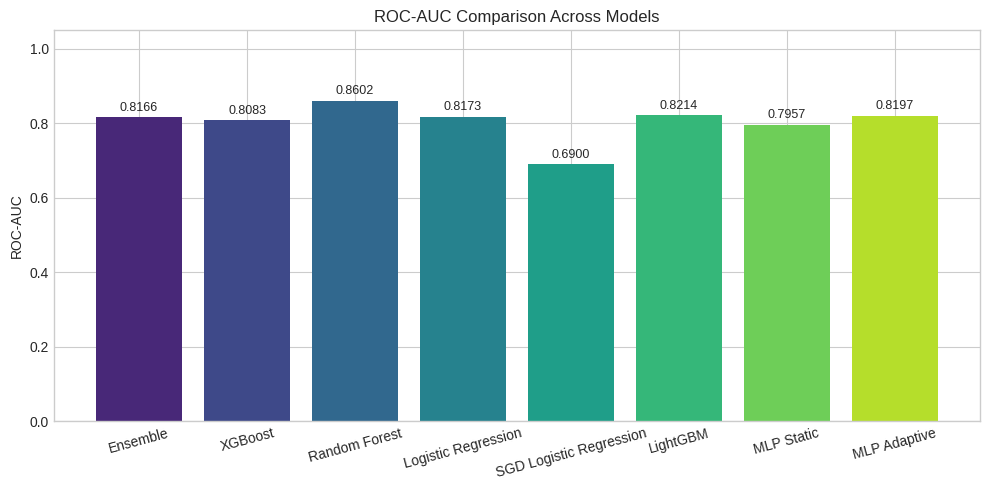

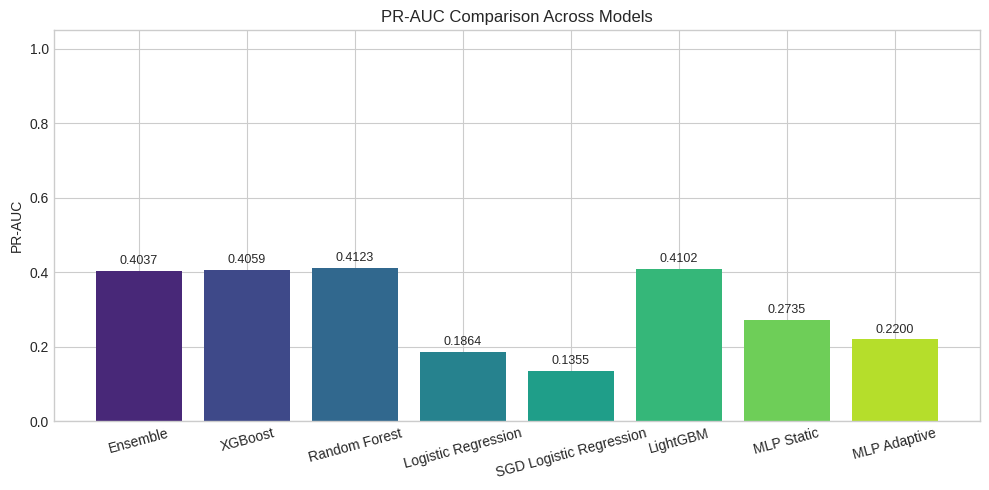

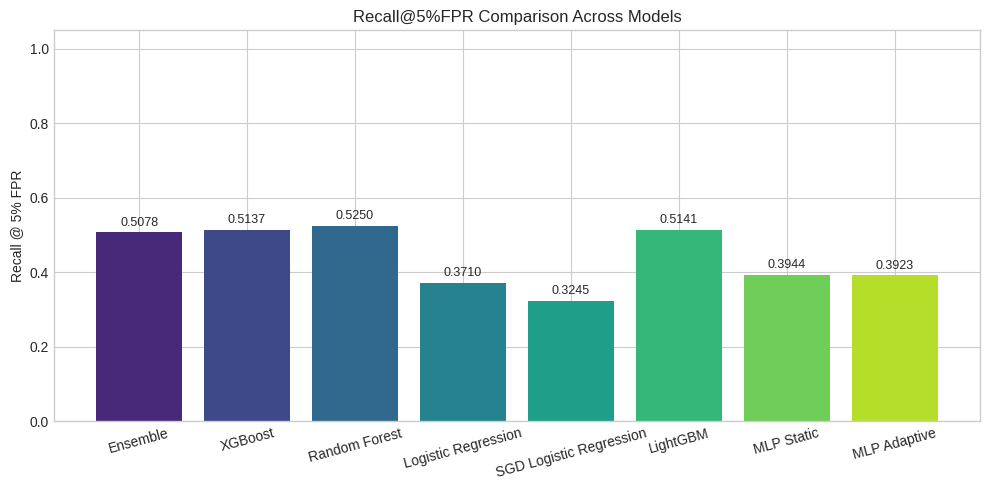

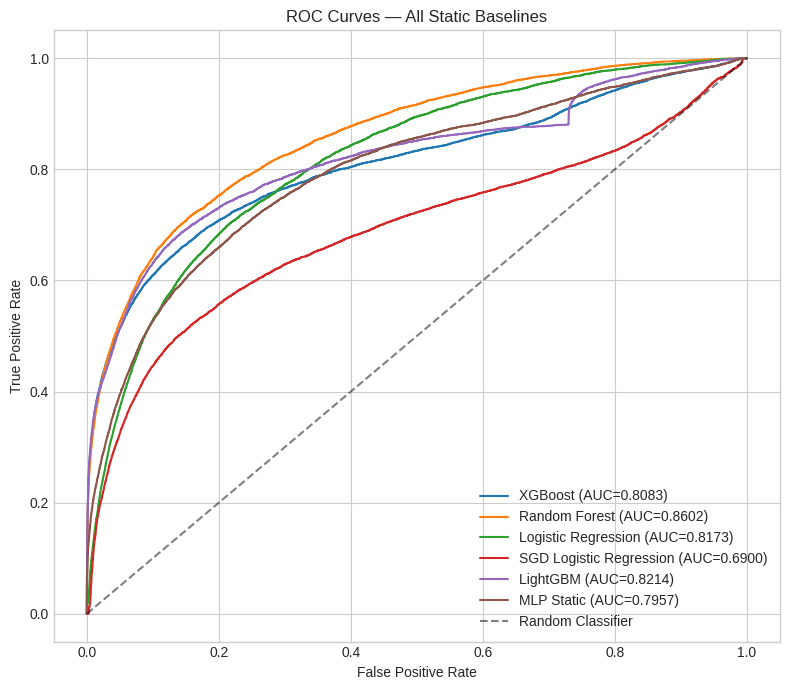

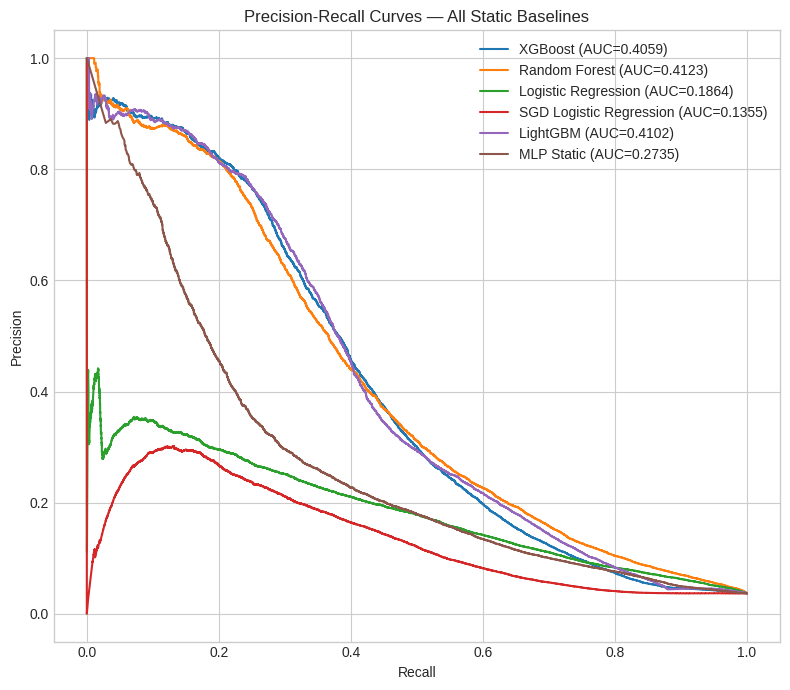

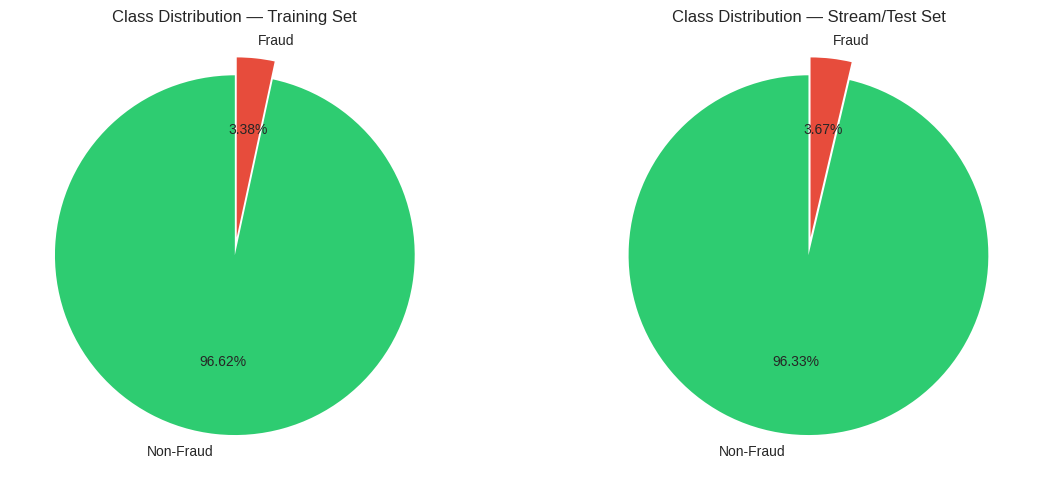

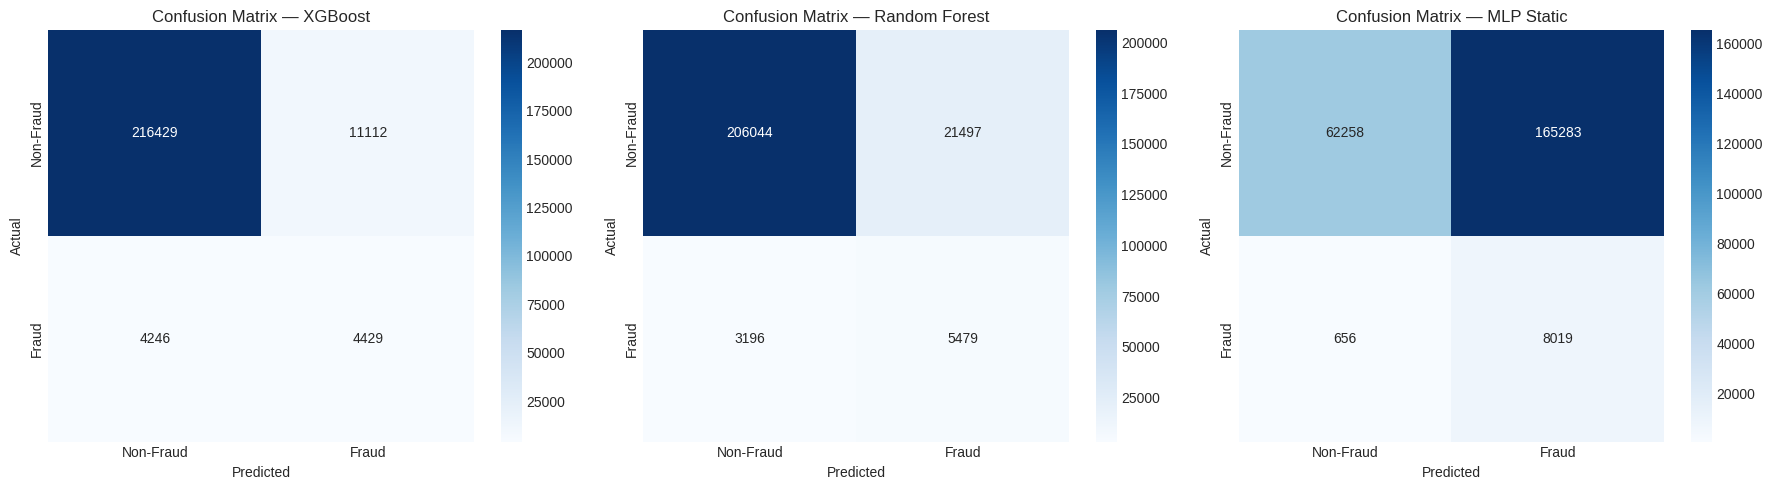

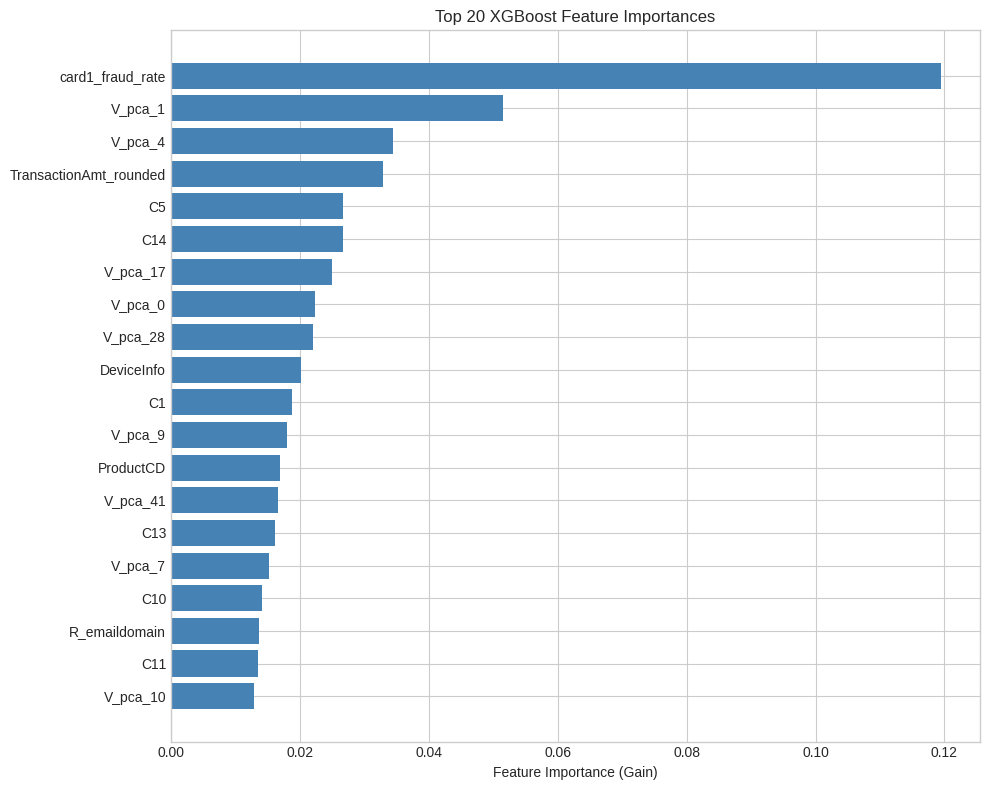

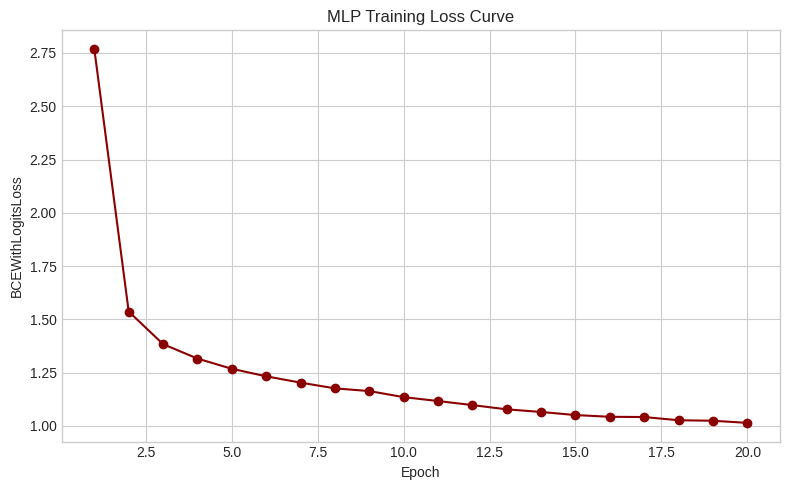


SUMMARY OF ALL MODEL METRICS
                  Model ROC-AUC PR-AUC Recall@5%FPR
               Ensemble  0.8166 0.4037       0.5078
                XGBoost  0.8083 0.4059       0.5137
          Random Forest  0.8602 0.4123       0.5250
    Logistic Regression  0.8173 0.1864       0.3710
SGD Logistic Regression  0.6900 0.1355       0.3245
               LightGBM  0.8214 0.4102       0.5141
             MLP Static  0.7957 0.2735       0.3944
           MLP Adaptive  0.8197 0.2200       0.3923


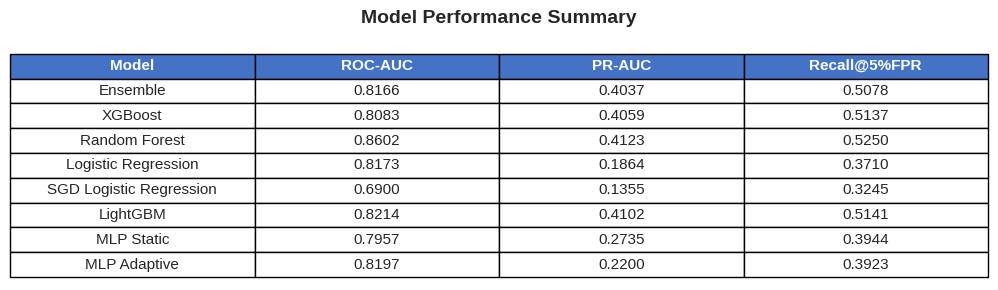

In [11]:
# --- Stacked Hybrid Model: RF + XGBoost + MLP (Holdout Stacking) ---
from sklearn.linear_model import LogisticRegression as StackingMetaLearner

print("\nBuilding Stacked Hybrid Model (RF + XGBoost + MLP)...")

# Level-0: Re-train base learners on 80% of historical data (same split as MLP training)
_val_split = int(0.8 * len(hist_df))
_train_sub = hist_df.iloc[:_val_split].reset_index(drop=True)
_val_sub   = hist_df.iloc[_val_split:].reset_index(drop=True)

_X_tr = _train_sub[feature_input_cols].values
_y_tr = _train_sub[target_col].values
_X_vl = _val_sub[feature_input_cols].values
_y_vl = _val_sub[target_col].values

# Random Forest base learner
_rf_base = RandomForestClassifier(
    n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
)
_rf_base.fit(_X_tr, _y_tr)
_vl_rf = _rf_base.predict_proba(_X_vl)[:, 1]

# XGBoost base learner
_xgb_base = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, scale_pos_weight=pos_weight.item(),
    eval_metric='auc', random_state=42
)
_xgb_base.fit(_X_tr, _y_tr)
_vl_xgb = _xgb_base.predict_proba(_X_vl)[:, 1]

# MLP base learner (reuse the already-trained static model)
_X_vl_t = torch.tensor(_X_vl, dtype=torch.float32).to(device)
model.eval()
with torch.no_grad():
    _vl_mlp = torch.sigmoid(model(_X_vl_t)).cpu().numpy().flatten()

# Level-1: Train Logistic Regression meta-learner on holdout stacked predictions
_meta_X_val = np.column_stack([_vl_rf, _vl_xgb, _vl_mlp])
_meta_clf = StackingMetaLearner(solver='lbfgs', C=1.0, max_iter=1000, random_state=42)
_meta_clf.fit(_meta_X_val, _y_vl)

# Level-0 base predictions on test (stream) set
_X_str = stream_df[feature_input_cols].values
_ts_rf  = _rf_base.predict_proba(_X_str)[:, 1]
_ts_xgb = _xgb_base.predict_proba(_X_str)[:, 1]
_X_str_t = torch.tensor(_X_str, dtype=torch.float32).to(device)
model.eval()
with torch.no_grad():
    _ts_mlp = torch.sigmoid(model(_X_str_t)).cpu().numpy().flatten()

# Level-1: Final stacked prediction
_meta_X_test = np.column_stack([_ts_rf, _ts_xgb, _ts_mlp])
stacked_probs   = _meta_clf.predict_proba(_meta_X_test)[:, 1]
stacked_metrics = compute_metrics(y_true_stream, stacked_probs)

print(f"\nStacked Hybrid (RF + XGBoost + MLP) — "
      f"ROC-AUC: {stacked_metrics['roc_auc']:.4f}, "
      f"PR-AUC: {stacked_metrics['pr_auc']:.4f}, "
      f"Recall@5%FPR: {stacked_metrics['recall_at_5fpr']:.4f}")

# Collect all model names, predictions, and metrics
all_models = {
    'Stacked Hybrid': {'preds': stacked_probs, 'metrics': stacked_metrics},
    'XGBoost': {'preds': y_pred_xgb, 'metrics': xgb_metrics},
    'Random Forest': {'preds': y_pred_rf, 'metrics': rf_metrics},
    'Logistic Regression': {'preds': y_pred_lr, 'metrics': lr_metrics},
    'SGD Logistic Regression': {'preds': y_pred_sgd, 'metrics': sgd_metrics},
    'LightGBM': {'preds': y_pred_lgb, 'metrics': lgb_metrics},
    'MLP Static': {'preds': mlp_static_probs, 'metrics': mlp_static_metrics},
    'MLP Adaptive': {'preds': None, 'metrics': mlp_adaptive_metrics},
}
model_names = list(all_models.keys())

# --- Plot 1: ROC-AUC Comparison Bar Chart ---
fig, ax = plt.subplots(figsize=(10, 5))
roc_aucs = [all_models[m]['metrics']['roc_auc'] for m in model_names]
colors = sns.color_palette('viridis', len(model_names))
bars = ax.bar(model_names, roc_aucs, color=colors)
ax.set_ylabel('ROC-AUC')
ax.set_title('ROC-AUC Comparison Across Models')
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, roc_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('roc_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: PR-AUC Comparison Bar Chart ---
fig, ax = plt.subplots(figsize=(10, 5))
pr_aucs = [all_models[m]['metrics']['pr_auc'] for m in model_names]
bars = ax.bar(model_names, pr_aucs, color=colors)
ax.set_ylabel('PR-AUC')
ax.set_title('PR-AUC Comparison Across Models')
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, pr_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('pr_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 3: Recall@5%FPR Comparison Bar Chart ---
fig, ax = plt.subplots(figsize=(10, 5))
recalls = [all_models[m]['metrics']['recall_at_5fpr'] for m in model_names]
bars = ax.bar(model_names, recalls, color=colors)
ax.set_ylabel('Recall @ 5% FPR')
ax.set_title('Recall@5%FPR Comparison Across Models')
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, recalls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('recall_at_5fpr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 4: Overlaid ROC Curves ---
fig, ax = plt.subplots(figsize=(8, 7))
for name in ['XGBoost', 'Random Forest', 'Logistic Regression', 'SGD Logistic Regression', 'LightGBM', 'MLP Static']:
    preds = all_models[name]['preds']
    fpr, tpr, _ = roc_curve(y_true_stream, preds)
    roc_val = all_models[name]['metrics']['roc_auc']
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_val:.4f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Static Baselines')
ax.legend(loc='lower right')
ax.grid(True)
plt.tight_layout()
plt.savefig('roc_curves_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 5: Overlaid Precision-Recall Curves ---
fig, ax = plt.subplots(figsize=(8, 7))
for name in ['XGBoost', 'Random Forest', 'Logistic Regression', 'SGD Logistic Regression', 'LightGBM', 'MLP Static']:
    preds = all_models[name]['preds']
    prec, rec, _ = precision_recall_curve(y_true_stream, preds)
    pr_val = all_models[name]['metrics']['pr_auc']
    ax.plot(rec, prec, label=f"{name} (AUC={pr_val:.4f})")
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Static Baselines')
ax.legend(loc='upper right')
ax.grid(True)
plt.tight_layout()
plt.savefig('pr_curves_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 6: Class Distribution Pie Chart ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, df_plot, title in [(axes[0], hist_df, 'Training Set'), (axes[1], stream_df, 'Stream/Test Set')]:
    counts = df_plot[target_col].value_counts()
    labels = ['Non-Fraud', 'Fraud']
    ax.pie(counts, labels=labels, autopct='%1.2f%%', startangle=90,
           colors=['#2ecc71', '#e74c3c'], explode=(0, 0.1))
    ax.set_title(f'Class Distribution — {title}')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 7: Confusion Matrix Heatmaps ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
threshold = 0.5
for ax, name, preds in [(axes[0], 'XGBoost', y_pred_xgb),
                         (axes[1], 'Random Forest', y_pred_rf),
                         (axes[2], 'MLP Static', mlp_static_probs)]:
    y_bin = (preds >= threshold).astype(int)
    cm = confusion_matrix(y_true_stream, y_bin)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 8: XGBoost Feature Importance (Top 20) ---
fig, ax = plt.subplots(figsize=(10, 8))
importances = xgb_feature_importances
sorted_idx = np.argsort(importances)[-20:] # Select only top 20
ax.barh(np.array(feature_input_cols)[sorted_idx], importances[sorted_idx], color='steelblue')
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('Top 20 XGBoost Feature Importances')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 10: Training Loss Curve ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(training_losses) + 1), training_losses, marker='o', color='darkred')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCEWithLogitsLoss')
ax.set_title('MLP Training Loss Curve')
ax.grid(True)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 11: Summary Metrics Table ---
print("\n" + "="*70)
print("SUMMARY OF ALL MODEL METRICS")
print("="*70)
summary_data = []
for name in model_names:
    m = all_models[name]['metrics']
    summary_data.append([name, f"{m['roc_auc']:.4f}", f"{m['pr_auc']:.4f}", f"{m['recall_at_5fpr']:.4f}"])

summary_df = pd.DataFrame(summary_data, columns=['Model', 'ROC-AUC', 'PR-AUC', 'Recall@5%FPR'])
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#4472C4')
        cell.set_text_props(color='white', fontweight='bold')
plt.title('Model Performance Summary', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('summary_table.png', dpi=150, bbox_inches='tight')
plt.show()

# 9C. Final Model Comparison Table

Comprehensive comparison of all models across key metrics:

In [12]:
# Create comprehensive model comparison table
results_df = pd.DataFrame({
    'Model': ['XGBoost', 'Random Forest', 'Logistic Regression', 'SGD Logistic Regression',
              'LightGBM', 'MLP Static', 'MLP Adaptive', 'Stacked Hybrid'],
    'ROC-AUC': [
        xgb_metrics['roc_auc'],
        rf_metrics['roc_auc'],
        lr_metrics['roc_auc'],
        sgd_metrics['roc_auc'],
        lgb_metrics['roc_auc'],
        mlp_static_metrics['roc_auc'],
        mlp_adaptive_metrics['roc_auc'],
        stacked_metrics['roc_auc']
    ],
    'PR-AUC': [
        xgb_metrics['pr_auc'],
        rf_metrics['pr_auc'],
        lr_metrics['pr_auc'],
        sgd_metrics['pr_auc'],
        lgb_metrics['pr_auc'],
        mlp_static_metrics['pr_auc'],
        mlp_adaptive_metrics['pr_auc'],
        stacked_metrics['pr_auc']
    ],
    'Recall@5%FPR': [
        xgb_metrics['recall_at_5fpr'],
        rf_metrics['recall_at_5fpr'],
        lr_metrics['recall_at_5fpr'],
        sgd_metrics['recall_at_5fpr'],
        lgb_metrics['recall_at_5fpr'],
        mlp_static_metrics['recall_at_5fpr'],
        mlp_adaptive_metrics['recall_at_5fpr'],
        stacked_metrics['recall_at_5fpr']
    ]
})

# Sort by ROC-AUC descending
results_df = results_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("FINAL MODEL COMPARISON")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# Highlight best performers
best_roc = results_df['ROC-AUC'].max()
best_pr = results_df['PR-AUC'].max()
best_recall = results_df['Recall@5%FPR'].max()

print(f"\n🏆 Best ROC-AUC: {best_roc:.4f} ({results_df.loc[results_df['ROC-AUC'] == best_roc, 'Model'].values[0]})")
print(f"🏆 Best PR-AUC: {best_pr:.4f} ({results_df.loc[results_df['PR-AUC'] == best_pr, 'Model'].values[0]})")
print(f"🏆 Best Recall@5%FPR: {best_recall:.4f} ({results_df.loc[results_df['Recall@5%FPR'] == best_recall, 'Model'].values[0]})")


FINAL MODEL COMPARISON
                  Model  ROC-AUC   PR-AUC  Recall@5%FPR
          Random Forest 0.860244 0.412341      0.524957
               LightGBM 0.821367 0.410222      0.514121
           MLP Adaptive 0.819742 0.220026      0.392303
    Logistic Regression 0.817299 0.186364      0.370951
               Ensemble 0.816553 0.403665      0.507781
                XGBoost 0.808334 0.405924      0.513660
             MLP Static 0.795722 0.273487      0.394352
SGD Logistic Regression 0.690025 0.135487      0.324496

🏆 Best ROC-AUC: 0.8602 (Random Forest)
🏆 Best PR-AUC: 0.4123 (Random Forest)
🏆 Best Recall@5%FPR: 0.5250 (Random Forest)


# 11. EXPORT

In [13]:
# Save all deployment artifacts for Streamlit app
import json
from pathlib import Path
import joblib
import torch
import os

ART_DIR = Path("results")
ART_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# 0) Config / metadata
# -------------------------
config = {
    "mc_dropout_T": 20,
    "flag_top_percent": 5.0,
    "n_input_features": int(len(feature_input_cols)),
    "pca_components": int(getattr(pca, "n_components_", getattr(pca, "n_components", 0))),
}
with open(ART_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)
print(f"Saved config.json → {ART_DIR / 'config.json'}")

# -------------------------
# 1) Preprocessing artifacts
# -------------------------
joblib.dump(feature_input_cols, ART_DIR / "feature_input_cols.pkl")
joblib.dump(te, ART_DIR / "target_encoder.pkl")
joblib.dump(scaler, ART_DIR / "scaler.pkl")
joblib.dump(pca, ART_DIR / "pca.pkl")

print(f"Saved feature_input_cols.pkl (len={len(feature_input_cols)})")
print("Saved target_encoder.pkl")
print("Saved scaler.pkl")
print("Saved pca.pkl")

# -------------------------
# 2) Numeric medians (for inference-time fill)
# -------------------------
medians = {}
for col in feature_input_cols:
    if col in hist_df.columns and hist_df[col].dtype != "O":
        medians[col] = float(hist_df[col].median())

with open(ART_DIR / "medians.json", "w") as f:
    json.dump(medians, f, indent=2)
print(f"Saved medians.json with {len(medians)} entries")

# -------------------------
# 3) Target mean fallback
# -------------------------
target_mean = float(hist_df[target_col].mean())
with open(ART_DIR / "target_mean.json", "w") as f:
    json.dump({"target_mean": target_mean}, f, indent=2)
print(f"Saved target_mean.json (target_mean={target_mean:.6f})")

# -------------------------
# 4) Card aggregation lookup tables
# -------------------------
for card_col in ["card1", "card2", "card3"]:
    if card_col in hist_df.columns:
        stats = hist_df.groupby(card_col)[target_col].agg(["mean", "count"]).reset_index()
        stats.columns = [card_col, f"{card_col}_fraud_rate", f"{card_col}_count"]
        out_path = ART_DIR / f"{card_col}_stats.parquet"
        stats.to_parquet(out_path, index=False)
        print(f"Saved {card_col}_stats.parquet (rows={len(stats)})")

# -------------------------
# 5) MLP model weights
# -------------------------
torch.save(model.state_dict(), ART_DIR / "mlp_state_dict.pt")
print(f"Saved mlp_state_dict.pt → {ART_DIR / 'mlp_state_dict.pt'}")

# -------------------------
# 6) XGBoost model check
# -------------------------
# We check if the file was created during the training step
xgb_path = ART_DIR / "xgb_model.json"
if xgb_path.exists():
    print(f"Confirmed: xgb_model.json exists at {xgb_path}")
    xgb_saved = True
else:
    print("WARNING: xgb_model.json not found in results directory.")
    xgb_saved = False

# -------------------------
# 7) Final sanity check
# -------------------------
required = [
    "feature_input_cols.pkl", "target_encoder.pkl", "scaler.pkl", "pca.pkl",
    "medians.json", "target_mean.json", "mlp_state_dict.pt", "config.json",
    "card1_stats.parquet", "card2_stats.parquet", "card3_stats.parquet", "xgb_model.json"
]

missing = [f for f in required if not (ART_DIR / f).exists()]
if missing:
    print("❌ Missing artifacts:", missing)
else:
    print("✅ All expected artifacts saved successfully.")

Saved config.json → results/config.json
Saved feature_input_cols.pkl (len=92)
Saved target_encoder.pkl
Saved scaler.pkl
Saved pca.pkl
Saved medians.json with 92 entries
Saved target_mean.json (target_mean=0.033833)
Saved card1_stats.parquet (rows=11735)
Saved card2_stats.parquet (rows=499)
Saved card3_stats.parquet (rows=102)
Saved mlp_state_dict.pt → results/mlp_state_dict.pt
Confirmed: xgb_model.json exists at results/xgb_model.json
✅ All expected artifacts saved successfully.


In [ ]:
import json
from pathlib import Path
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

ART_DIR = Path("results")
ART_DIR.mkdir(parents=True, exist_ok=True)

# --- 1. Export Metrics Comparison ---
metrics_comparison_data = results_df.to_dict(orient='records')
with open(ART_DIR / "metrics_comparison.json", "w") as f:
    json.dump(metrics_comparison_data, f, indent=2)
print("Saved metrics_comparison.json")

# --- 2. Export ROC Curves data ---
roc_curves_data = []
for name in ['XGBoost', 'Random Forest', 'Logistic Regression', 'SGD Logistic Regression', 'LightGBM', 'MLP Static']:
    preds = all_models[name]['preds']
    fpr, tpr, _ = roc_curve(y_true_stream, preds)
    roc_curves_data.append({
        'model': name,
        'fpr': fpr.tolist(),
        'tpr': tpr.tolist(),
        'roc_auc': all_models[name]['metrics']['roc_auc']
    })
with open(ART_DIR / "roc_curves.json", "w") as f:
    json.dump(roc_curves_data, f, indent=2)
print("Saved roc_curves.json")

# --- 3. Export PR Curves data ---
pr_curves_data = []
for name in ['XGBoost', 'Random Forest', 'Logistic Regression', 'SGD Logistic Regression', 'LightGBM', 'MLP Static']:
    preds = all_models[name]['preds']
    prec, rec, _ = precision_recall_curve(y_true_stream, preds)
    pr_curves_data.append({
        'model': name,
        'precision': prec.tolist(),
        'recall': rec.tolist(),
        'pr_auc': all_models[name]['metrics']['pr_auc']
    })
with open(ART_DIR / "pr_curves.json", "w") as f:
    json.dump(pr_curves_data, f, indent=2)
print("Saved pr_curves.json")

# --- 4. Export Confusion Matrices ---
confusion_matrices_data = {}
threshold = 0.5
for name, preds in [('XGBoost', y_pred_xgb),
                     ('Random Forest', y_pred_rf),
                     ('MLP Static', mlp_static_probs)]:
    y_bin = (preds >= threshold).astype(int)
    cm = confusion_matrix(y_true_stream, y_bin)
    confusion_matrices_data[name] = cm.tolist()
with open(ART_DIR / "confusion_matrices.json", "w") as f:
    json.dump(confusion_matrices_data, f, indent=2)
print("Saved confusion_matrices.json")

Saved metrics_comparison.json
Saved roc_curves.json
Saved pr_curves.json
Saved confusion_matrices.json
